<a href="https://colab.research.google.com/github/HY-BME/bme_test_files/blob/%EB%B0%94%EC%9D%B4%EC%98%A4%EA%B3%B5%ED%95%99%EC%98%A4%ED%94%88%EC%86%8C%EC%8A%A4%EA%B8%B0%EC%88%A0/ML_diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

#스마트 당뇨병 스크리닝 모델 구축
#환자의 건강 지표 데이터를 분석하여 당뇨병 여부를 예측하는 분류(Classification) 모델 생성 후 검증
#분류(Classification) 모델 형성과 특성 중요도 파악 필요. 교차검증은 RMSE가 아닌 정확도 검사로 진행

df = pd.read_csv('/content/sample_data/diabetes.csv')

# features (X) 및 target (y) 정의
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# 0.2 = 80% train set, 20% test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set shape: ', X_train.shape)
print('Testing set shape: ', X_test.shape)

df.head()


Training set shape:  (614, 8)
Testing set shape:  (154, 8)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


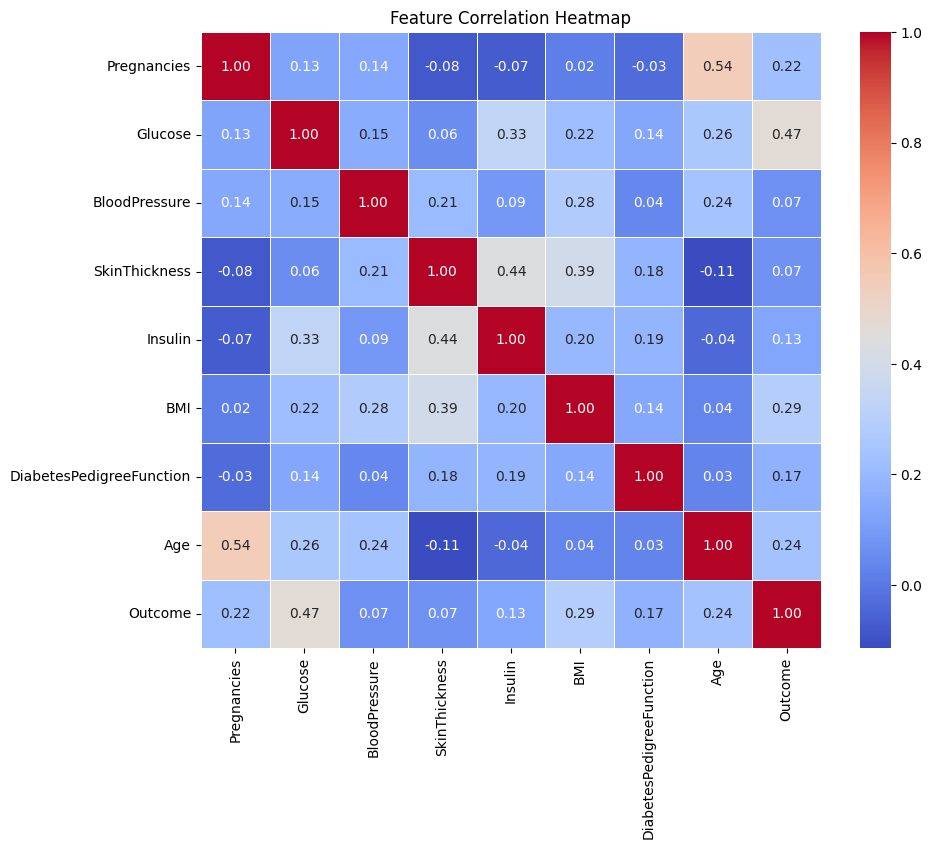

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 상관계수 행렬 계산
correlation_matrix = df.corr(numeric_only=True)

# 2. 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

# Outcome(타겟)과의 상관관계만 따로 보기
print(correlation_matrix['Outcome'].sort_values(ascending=False))

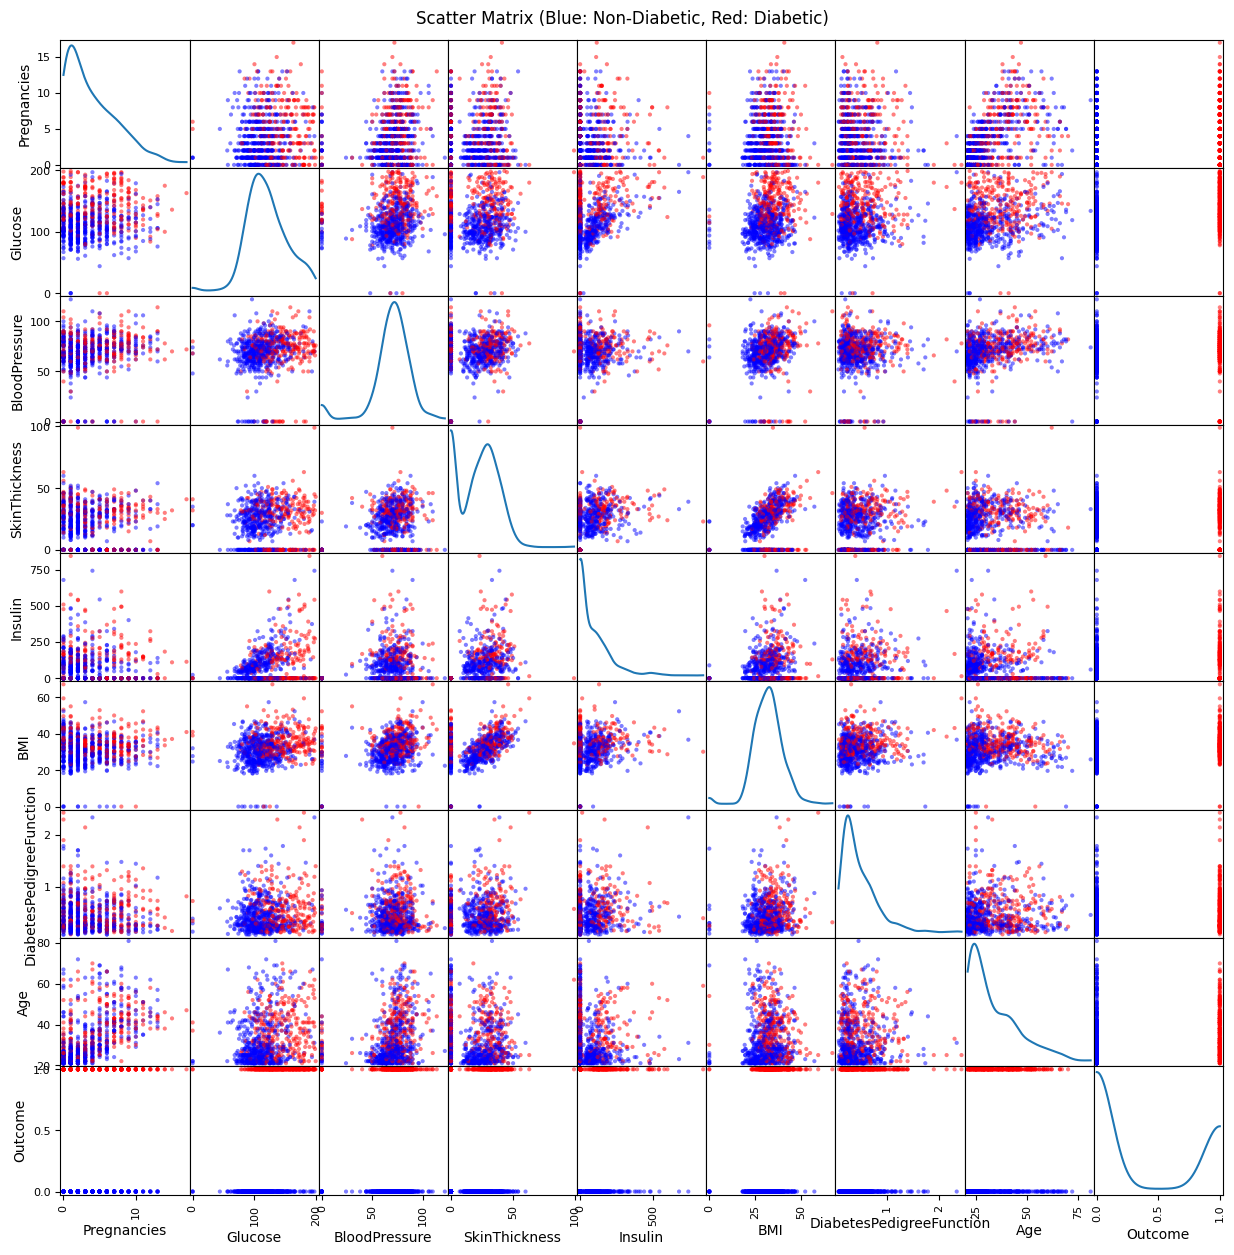

In [29]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

colors = df['Outcome'].map({0: 'blue', 1: 'red'})

scatter_matrix(df, alpha=0.5, figsize=(15, 15), diagonal='kde', c=colors)
plt.suptitle('Scatter Matrix (Blue: Non-Diabetic, Red: Diabetic)', y=0.9)
plt.show()

In [30]:
# 원본 데이터셋 보호를 위해 Train set의 복사본 생성
X_train_copy = X_train.copy()
y_train_copy = y_train.copy()

In [31]:
from sklearn.impute import KNNImputer
import numpy as np

#결측치, 이상치 제거
risk_factors = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 0을 NaN으로 변환 (복사본 사용) : KNN imputer 사용(KNN 알고리즘을 사용하여 결측치를 채움)
X_train_imputed = X_train_copy.copy()
X_test_imputed = X_test.copy()

X_train_imputed[risk_factors] = X_train_imputed[risk_factors].replace(0, np.nan)
X_test_imputed[risk_factors] = X_test_imputed[risk_factors].replace(0, np.nan)

# KNN imputer
imputer = KNNImputer(n_neighbors=5)

# fit_transform을 사용하여 결측치를 대체
X_train_imputed[risk_factors] = imputer.fit_transform(X_train_imputed[risk_factors])
X_test_imputed[risk_factors] = imputer.transform(X_test_imputed[risk_factors])

display(X_train_imputed.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,1,90.0,62.0,12.0,43.0,27.2,0.580,24
711,5,126.0,78.0,27.0,22.0,29.6,0.439,40
373,2,105.0,58.0,40.0,94.0,34.9,0.225,25
46,1,146.0,56.0,31.8,142.6,29.7,0.564,29
682,0,95.0,64.0,39.0,105.0,44.6,0.366,22


In [32]:
from sklearn.preprocessing import StandardScaler

#StandardScaler 스케일링 진행
scaler = StandardScaler()

X_train_imputed = scaler.fit_transform(X_train_imputed)
X_test_imputed = scaler.transform(X_test_imputed)

display(X_train_imputed)
display(X_test_imputed)

array([[-0.85135507, -1.05937783, -0.82617889, ..., -0.77023934,
         0.31079384, -0.79216928],
       [ 0.35657564,  0.14070456,  0.47331539, ..., -0.41879498,
        -0.11643851,  0.56103382],
       [-0.5493724 , -0.5593435 , -1.15105246, ...,  0.3573113 ,
        -0.76486207, -0.70759409],
       ...,
       [-0.85135507, -0.82602847, -0.17643175, ...,  0.82590377,
        -0.78607218, -0.28471812],
       [ 1.86648903, -0.35932977, -0.17643175, ..., -0.72630879,
        -1.01938346,  0.56103382],
       [ 0.05459296,  0.74074575, -1.15105246, ..., -0.4334385 ,
        -0.57700104,  0.30730824]])

array([[ 0.96054099,  1.24078007, -0.6637421 , ..., -0.74095231,
        -0.55579092,  0.56103382],
       [ 1.86648903, -1.79276151,  2.74743039, ...,  0.44517239,
        -0.58306107,  1.15306018],
       [-0.5493724 ,  0.00736207,  0.31087861, ...,  0.50374645,
         0.01688223, -0.6230189 ],
       ...,
       [-0.5493724 , -1.3260628 , -1.63836281, ..., -0.57987364,
         3.70138246, -0.70759409],
       [ 0.05459296,  2.07417062,  0.47331539, ...,  0.66482511,
        -0.64669142, -0.20014293],
       [-0.85135507, -1.69275464,  0.47331539, ...,  0.10837155,
        -0.16794879, -1.04589487]])

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

#모델학습

# 1. LogisticRegression
lg_model = LogisticRegression(max_iter=1000, random_state=42)
lg_model.fit(X_train_imputed, y_train_copy)
lg_train_pred = lg_model.predict(X_train_imputed) #Train set
lg_test_pred = lg_model.predict(X_test_imputed) #Test set

# 2. DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_imputed, y_train_copy)
dt_train_pred = dt_model.predict(X_train_imputed)
dt_test_pred = dt_model.predict(X_test_imputed)

# 3. RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_imputed, y_train_copy)
rf_train_pred = rf_model.predict(X_train_imputed)
rf_test_pred = rf_model.predict(X_test_imputed)

#-------------- Train Set 성능 평가 ------------------------#
print("Train Set")
print("\n--- Logistic Regression ---")
print(f"Train Accuracy: {accuracy_score(y_train_copy, lg_train_pred):.4f}")
print("Train Confusion Matrix:")
print(confusion_matrix(y_train_copy, lg_train_pred))

print("\n--- Decision Tree ---")
print(f"Train Accuracy: {accuracy_score(y_train_copy, dt_train_pred):.4f}")
print("Train Confusion Matrix:")
print(confusion_matrix(y_train_copy, dt_train_pred))

print("\n--- Random Forest ---")
print(f"Train Accuracy: {accuracy_score(y_train_copy, rf_train_pred):.4f}")
print("Train Confusion Matrix:")
print(confusion_matrix(y_train_copy, rf_train_pred))


#-------------- Test Set 성능 평가 ------------------------#
print("\n\n\nTest Set")
print(f"\n--- Logistic Regression ---")
print(f"Test Accuracy: {accuracy_score(y_test, lg_test_pred):.4f}")
print("Test Confusion Matrix:")
print(confusion_matrix(y_test, lg_test_pred))

print("\n--- Decision Tree ---")
print(f"Test Accuracy: {accuracy_score(y_test, dt_test_pred):.4f}")
print("Test Confusion Matrix:")
print(confusion_matrix(y_test, dt_test_pred))

print("\n--- Random Forest ---")
print(f"Test Accuracy: {accuracy_score(y_test, rf_test_pred):.4f}")
print("Test Confusion Matrix:")
print(confusion_matrix(y_test, rf_test_pred))

Train Set

--- Logistic Regression ---
Train Accuracy: 0.7964
Train Confusion Matrix:
[[361  39]
 [ 86 128]]

--- Decision Tree ---
Train Accuracy: 1.0000
Train Confusion Matrix:
[[400   0]
 [  0 214]]

--- Random Forest ---
Train Accuracy: 1.0000
Train Confusion Matrix:
[[400   0]
 [  0 214]]



Test Set

--- Logistic Regression ---
Test Accuracy: 0.6948
Test Confusion Matrix:
[[80 20]
 [27 27]]

--- Decision Tree ---
Test Accuracy: 0.6688
Test Confusion Matrix:
[[80 20]
 [31 23]]

--- Random Forest ---
Test Accuracy: 0.7338
Test Confusion Matrix:
[[83 17]
 [24 30]]


In [34]:
#훈련 데이터 교차 검증
from sklearn.model_selection import StratifiedKFold, cross_val_score

# K Fold 교차검증(Cross Validation) 설정 //분류 모델 : StratifiedKFold
#n_splits = 5 : 전체 데이터를 5조각으로 나눔. 총 5번의 학습과 평가(4개는 학습용, 1개는 검증용으로 반복 검증 후 결과값의 평균을 냄)
#random_state=42 : 난수고정. 데이터를 섞을 때(shuffle=True) 무작위성을 고정. 다음에 실행해도 똑같은 결과가 나오도록 함
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression
lg_cv_scores = cross_val_score(lg_model, X_train_imputed, y_train_copy, cv=kfold, scoring='accuracy')
print("훈련 데이터 선형회귀 모델 교차검증 : ", lg_cv_scores)
print("훈련 데이터 선형회귀 모델 교차검증 평균 :", lg_cv_scores.mean())

# Decision Tree
dt_cv_scores = cross_val_score(dt_model, X_train_imputed, y_train_copy, cv=kfold, scoring='accuracy')
print("훈련 데이터 결정트리 모델 교차검증: ", dt_cv_scores)
print("훈련 데이터 결정트리 모델 교차검증 평균 : ", dt_cv_scores.mean())

# Random Forest
rf_cv_scores = cross_val_score(rf_model, X_train_imputed, y_train_copy, cv=kfold, scoring='accuracy')
print("훈련 데이터 랜덤포레스트 모델 교차검증 : ", rf_cv_scores)
print("훈련 데이터 랜덤포레스트 모델 교차검증 평균: ", rf_cv_scores.mean())

훈련 데이터 선형회귀 모델 교차검증 :  [0.80487805 0.78861789 0.82113821 0.78861789 0.76229508]
훈련 데이터 선형회귀 모델 교차검증 평균 : 0.7931094228975076
훈련 데이터 결정트리 모델 교차검증:  [0.69105691 0.57723577 0.69105691 0.70731707 0.6557377 ]
훈련 데이터 결정트리 모델 교차검증 평균 :  0.6644808743169399
훈련 데이터 랜덤포레스트 모델 교차검증 :  [0.79674797 0.7804878  0.82113821 0.77235772 0.76229508]
훈련 데이터 랜덤포레스트 모델 교차검증 평균:  0.7866053578568573


In [35]:
from sklearn.model_selection import GridSearchCV

print("\n\n --------------- LogisticRegression Model Grid Search ---------------- \n\n")

# 선형회귀모델 Grid Search 진행
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

grid_search = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid, cv=kfold, scoring='accuracy')

# Train set 학습
grid_search.fit(X_train_imputed, y_train_copy)

print("Train set LogisticRegression Parameters: ", grid_search.best_params_)
print("Train set LogisticRegression CV Score:", grid_search.best_score_)

# Test set 평가
best_lg_model = grid_search.best_estimator_
test_acc = best_lg_model.score(X_test_imputed, y_test)
print("LogisticRegression Test Accuracy: ", test_acc)

print("\n\n --------------- RandomForest Model Grid Search ---------------- \n\n")

# Random Forest 하이퍼파라미터 그리드 설정 Grid Search 진행
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearchCV 설정
rf_grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1
)

# Train set 학습
rf_grid_search.fit(X_train_imputed, y_train_copy)

print("Train set RandomForest Parameters: ", rf_grid_search.best_params_)
print("Train set RandomForest CV Score: ", rf_grid_search.best_score_)

# Test set 평가
best_rf_model = rf_grid_search.best_estimator_
rf_test_acc = best_rf_model.score(X_test_imputed, y_test)
print(f"RandomForest Test Accuracy: ", rf_test_acc)



 --------------- LogisticRegression Model Grid Search ---------------- 


Train set LogisticRegression Parameters:  {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Train set LogisticRegression CV Score: 0.7963614554178329
LogisticRegression Test Accuracy:  0.6948051948051948


 --------------- RandomForest Model Grid Search ---------------- 


Train set RandomForest Parameters:  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Train set RandomForest CV Score:  0.7866053578568573
RandomForest Test Accuracy:  0.7337662337662337


In [36]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Logistic Regression Random Search
lg_rand_grid = {
    'C': uniform(0.01, 100),
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

lg_random_search = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_distributions=lg_rand_grid,
    n_iter=20,
    cv=kfold,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

lg_random_search.fit(X_train_imputed, y_train_copy)
print("--- Train set Logistic Regression Random Search ---")
print(f"Best Parameters: {lg_random_search.best_params_}")
print(f"Best CV Score: {lg_random_search.best_score_:.4f}")

# Random Forest Random Search
rf_rand_grid = {
    'n_estimators': randint(100, 500),
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'bootstrap': [True, False]
}

rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_rand_grid,
    n_iter=20,
    cv=kfold,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train_imputed, y_train_copy)
print("\n--- Train set Random Forest Random Search ---")
print("Best Parameters: ", rf_random_search.best_params_)
print("Best CV Score : ", rf_random_search.best_score_)

--- Train set Logistic Regression Random Search ---
Best Parameters: {'C': np.float64(37.464011884736244), 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Score: 0.7947

--- Train set Random Forest Random Search ---
Best Parameters:  {'bootstrap': True, 'max_depth': 40, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 108}
Best CV Score :  0.7849526855924297


In [37]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Test set Logistic Regression Random Search
best_lg = lg_random_search.best_estimator_
lg_final_test_acc = best_lg.score(X_test_imputed, y_test)
print("\n--- Test set Logistic Regression Random Search ---")
print(f'Logistic Regression Test accuracy: {lg_final_test_acc:.4f}')

# Test set Random Forest Random Search
best_rf = rf_random_search.best_estimator_
rf_final_test_acc = best_rf.score(X_test_imputed, y_test)

print("\n--- Test set Random Forest Random Search ---")
print(f'Random Forest Test accuracy: {rf_final_test_acc:.4f}')


--- Test set Logistic Regression Random Search ---
Logistic Regression Test accuracy: 0.6948

--- Test set Random Forest Random Search ---
Random Forest Test accuracy: 0.7338


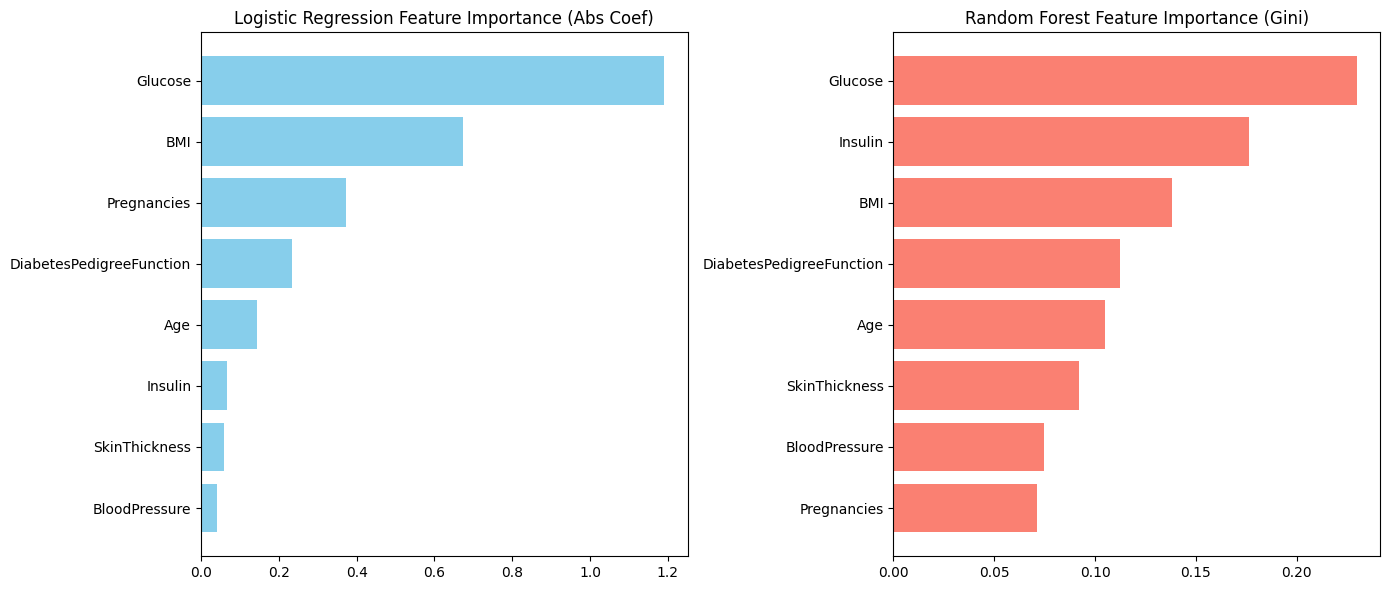

,Feature,Importance
1,Glucose,1.191035
5,BMI,0.674290
0,Pregnancies,0.372342
6,DiabetesPedigreeFunction,0.234220
7,Age,0.145192
4,Insulin,0.066280
3,SkinThickness,0.059416
2,BloodPressure,0.041994


,Feature,Importance
1,Glucose,0.229872
4,Insulin,0.176621
5,BMI,0.137931
6,DiabetesPedigreeFunction,0.112452
7,Age,0.104976
3,SkinThickness,0.091927
2,BloodPressure,0.074819
0,Pregnancies,0.071402


In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Logistic Regression 특성 중요도
# 선형 모델에서는 회귀 계수의 절대값이 클수록 영향력이 큼
lg_importance = np.abs(best_lg_model.coef_[0])
lg_features = pd.DataFrame({'Feature': X_train_copy.columns, 'Importance': lg_importance})
lg_features = lg_features.sort_values(by='Importance', ascending=False)

# Random Forest 특성 중요도 : 지니계수
rf_importance = best_rf_model.feature_importances_
rf_features = pd.DataFrame({'Feature': X_train_copy.columns, 'Importance': rf_importance})
rf_features = rf_features.sort_values(by='Importance', ascending=False)

# 시각화
plt.figure(figsize=(14, 6))

# Logistic Regression Plot
plt.subplot(1, 2, 1)
plt.barh(lg_features['Feature'], lg_features['Importance'], color='skyblue')
plt.title('Logistic Regression Feature Importance (Abs Coef)')
plt.gca().invert_yaxis()

# Random Forest Plot
plt.subplot(1, 2, 2)
plt.barh(rf_features['Feature'], rf_features['Importance'], color='salmon')
plt.title('Random Forest Feature Importance (Gini)')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

display(lg_features)
display(rf_features)

In [39]:
#특성(feature) 추가 : 특성 엔지니어링 실행 후 재검증 작업

def apply_feature_engineering(df_in):
    df = df_in.copy()
    # NumPy array인 경우 DataFrame으로 변환 (컬럼명 복구)
    if isinstance(df, np.ndarray):
        df = pd.DataFrame(df, columns=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'])

    df['Metabolic'] = df['Glucose'] * df['BMI']
    df['BMI_Glucose_Ratio'] = df['BMI'] / (df['Glucose'] + 1)
    df['InsulinResistance'] = df['Insulin'] / (df['Glucose'] + 1)
    return df

# NumPy 배열을 데이터프레임으로 변환하여 함수 적용
X_train_fe = apply_feature_engineering(X_train_imputed)
X_test_fe = apply_feature_engineering(X_test_imputed)

# Retrain Logistic Regression
final_lg = LogisticRegression(max_iter=1000, C=1, solver='liblinear', random_state=42)
final_lg.fit(X_train_fe, y_train_copy)

fe_score = final_lg.score(X_test_fe, y_test)
print("LogisticRegression Test set : ", fe_score)

final_rf = RandomForestClassifier(
    bootstrap=True,
    max_depth=40,
    min_samples_leaf=1,
    min_samples_split=8,
    n_estimators=108,
    random_state=42
)

# Retrain RandomForestClassifier
final_rf.fit(X_train_fe, y_train_copy)

fe_rf_score = final_rf.score(X_test_fe, y_test)
print("RandomForestClassifier Test set : ", fe_rf_score)

LogisticRegression Test set :  0.6948051948051948
RandomForestClassifier Test set :  0.7402597402597403


In [40]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# K Fold setting
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("--- Featuring 후 Train set 교차검증 ---")

# Logistic Regression CV
lg_fe_cv_scores = cross_val_score(final_lg, X_train_fe, y_train_copy, cv=kfold, scoring='accuracy')
print("\n[Logistic Regression]")
print(f"CV Scores: {lg_fe_cv_scores}")
print(f"Best CV Score (Mean): {lg_fe_cv_scores.mean():.4f}")

# Random Forest CV
rf_fe_cv_scores = cross_val_score(final_rf, X_train_fe, y_train_copy, cv=kfold, scoring='accuracy')
print("\n[Random Forest]")
print(f"CV Scores: {rf_fe_cv_scores}")
print(f"Best CV Score (Mean): {rf_fe_cv_scores.mean():.4f}")

--- Featuring 후 Train set 교차검증 ---

[Logistic Regression]
CV Scores: [0.79674797 0.7804878  0.80487805 0.78861789 0.7704918 ]
Best CV Score (Mean): 0.7882

[Random Forest]
CV Scores: [0.79674797 0.7398374  0.82926829 0.75609756 0.78688525]
Best CV Score (Mean): 0.7818


In [26]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

lg_rand_grid_fe = {
    'C': uniform(0.01, 100),
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

# RandomizedSearchCV
lg_random_search_fe = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_distributions=lg_rand_grid_fe,
    n_iter=50,
    cv=kfold,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

lg_random_search_fe.fit(X_train_fe, y_train_copy)

print("Logistic Regression Random Search (Feature Engineering)")
print("Best Parameters: " , lg_random_search_fe.best_params_)
print("Best CV Score: ", lg_random_search_fe.best_score_)

best_lg_fe = lg_random_search_fe.best_estimator_
test_acc_fe = best_lg_fe.score(X_test_fe, y_test)
print("Logistic Regression Random Search Test set : ", test_acc_fe)

rf_rand_grid_fe = {
    'n_estimators': randint(100, 500),
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'bootstrap': [True, False]
}

# Initialize RandomizedSearchCV
rf_random_search_fe = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_rand_grid_fe,
    n_iter=20,
    cv=kfold,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

rf_random_search_fe.fit(X_train_fe, y_train_copy)

print("Random Forest Random Search (Feature Engineering)")
print("Best RF Parameters: " , rf_random_search_fe.best_params_)
print("Best RF CV Score: " , rf_random_search_fe.best_score_)


best_rf_fe = rf_random_search_fe.best_estimator_
rf_test_acc_fe = best_rf_fe.score(X_test_fe, y_test)
print("Random Forest Random Search Test set : ", rf_test_acc_fe)

Logistic Regression Random Search (Feature Engineering)
Best Parameters:  {'C': np.float64(59.87584841970366), 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Score:  0.7914967346394775
Logistic Regression Random Search Test set :  0.7012987012987013
Random Forest Random Search (Feature Engineering)
Best RF Parameters:  {'bootstrap': True, 'max_depth': 20, 'min_samples_leaf': 8, 'min_samples_split': 5, 'n_estimators': 459}
Best RF CV Score:  0.7882713581234173
Random Forest Random Search Test set :  0.7077922077922078


In [41]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

y_pred_rf_rs = best_rf_fe.predict(X_test_fe)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred_rf_rs):.4f}")

print("classification_report")
print(classification_report(y_test, y_pred_rf_rs))

print("Confusion Matrix")
cm_rf_rs = confusion_matrix(y_test, y_pred_rf_rs)
display(pd.DataFrame(cm_rf_rs, index=['Actual 0', 'Actual 1'], columns=['Predict 0', 'Predict 1']))

Test Accuracy: 0.7078
classification_report
              precision    recall  f1-score   support

           0       0.76      0.81      0.78       100
           1       0.60      0.52      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154

Confusion Matrix


,Predict 0,Predict 1
Actual 0,81,19
Actual 1,26,28


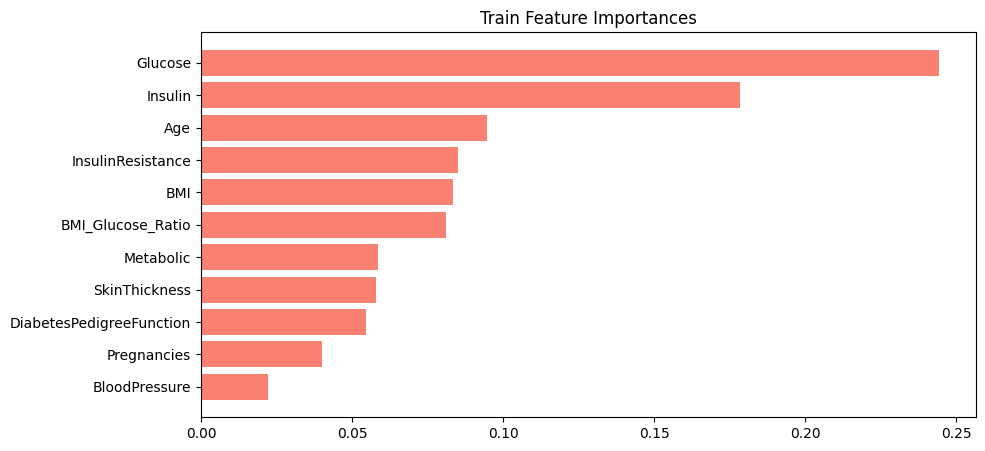

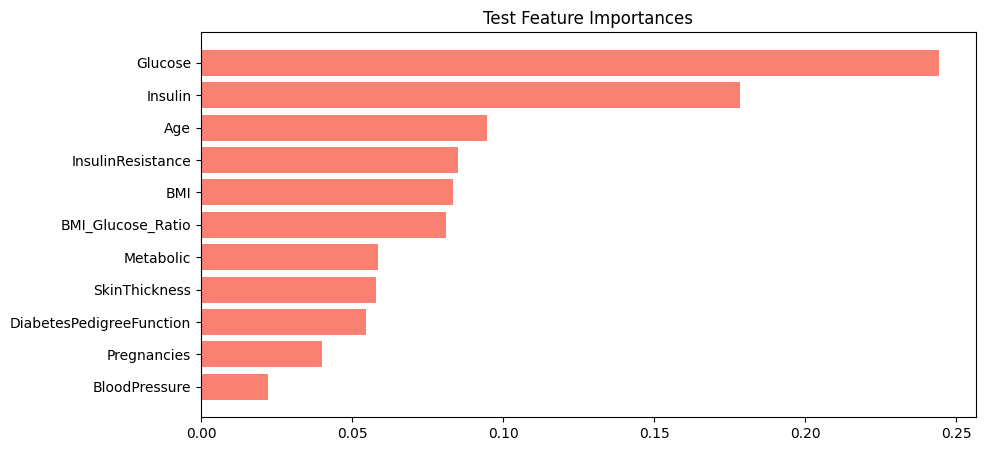

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# train 특성 중요도
importances = best_rf_fe.feature_importances_
feature_names = X_train_fe.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# 시각화
plt.figure(figsize=(10, 5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='salmon')
plt.gca().invert_yaxis()
plt.title('Train Feature Importances')
plt.show()

# test 특성 중요도
importances = best_rf_fe.feature_importances_
feature_names = X_test_fe.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# 시각화
plt.figure(figsize=(10, 5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='salmon')
plt.gca().invert_yaxis()
plt.title('Test Feature Importances')
plt.show()

In [96]:
from sklearn.metrics import recall_score, precision_score, precision_recall_curve, accuracy_score, classification_report
import numpy as np
import pandas as pd

# 높은 재현율을 위한 특성 추가 함수 수정
def apply_advanced_fe(df_in):
    df = df_in.copy()
    # NumPy array인 경우 DataFrame으로 변환 (컬럼명 복구)
    if isinstance(df, np.ndarray):
        df = pd.DataFrame(df, columns=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'])

    df['Age_Glucose'] = df['Age'] * df['Glucose']
    # Age가 스케일링된 값일 수 있으므로 분모가 0이 되지 않도록 처리 (원본 Age 기준 약 12세 이상 가정)
    df['Pregnancy_Freq'] = df['Pregnancies'] / (df['Age'] + 1)
    return df

X_train_adv = apply_advanced_fe(X_train_imputed)
X_test_adv = apply_advanced_fe(X_test_imputed)

# 모델 학습 : RandomForestClassifier
rf_high_recall = RandomForestClassifier(n_estimators=200, random_state=42)
rf_high_recall.fit(X_train_adv, y_train_copy)

# 임계값 조정. 목표 : 92% Recall
y_probs = rf_high_recall.predict_proba(X_test_adv)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# 타겟 재현율 92% 이상인 지점 중 가장 큰 임계값 찾기
target_recall = 0.68
# recalls >= target_recall을 만족하는 인덱스들 중 마지막 값(보통 가장 높은 precision을 가짐)
suitable_indices = np.where(recalls >= target_recall)[0]

if len(suitable_indices) > 0:
    idx = suitable_indices[-1]
    # thresholds는 recalls보다 길이가 1 짧으므로 인덱스 조정
    optimal_threshold = thresholds[min(idx, len(thresholds)-1)]

    y_pred_92 = (y_probs >= optimal_threshold).astype(int)

    print(f'Adjusted Threshold for {target_recall*100}% Recall: {optimal_threshold:.4f}')
    print(f'Test Accuracy: {accuracy_score(y_test, y_pred_92):.4f}')
    print(f'Test Recall: {recall_score(y_test, y_pred_92):.4f}')
    print(f'Test Precision: {precision_score(y_test, y_pred_92):.4f}')
    print(f"\nClassification Report at {target_recall*100}% Recall Threshold:")
    print(classification_report(y_test, y_pred_92))
else:
    print(f"{target_recall*100}% 재현율을 만족하는 임계값을 찾을 수 없습니다.")

Adjusted Threshold for 68.0% Recall: 0.4350
Test Accuracy: 0.7338
Test Recall: 0.6852
Test Precision: 0.6066

Classification Report at 68.0% Recall Threshold:
              precision    recall  f1-score   support

           0       0.82      0.76      0.79       100
           1       0.61      0.69      0.64        54

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.72       154
weighted avg       0.74      0.73      0.74       154



In [100]:
import numpy as np
import pandas as pd

# 당뇨환자 예측함수
def predict_diabetes_simple(glucose, insulin, bmi, age, dpf, pregnancies, bp, skin, threshold=0.4350):
    # 1. 모든 8개 원본 특성을 포함하는 DataFrame 생성
    data = pd.DataFrame([[pregnancies, glucose, bp, skin, insulin, bmi, dpf, age]],
                        columns=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'])

    # 2. 모델 학습 시 사용했던 advanced_fe 적용 (Age_Glucose 등 생성)
    new_data = apply_advanced_fe(data)

    # 3. 예측 확률 계산
    prob = rf_high_recall.predict_proba(new_data)[0][1]
    prediction = 1 if prob >= threshold else 0

    return {
        'Diagnosis': '양성(Positive)' if prediction == 1 else '음성(Negative)'
           }

# 1. 모든 항목에 대한 샘플 데이터 설정
test_pregnancies = 1
test_glucose = 85
test_bp = 66
test_skin = 29
test_insulin = 0
test_bmi = 26.6
test_dpf = 0.351
test_age = 31

# 2. 스케일러 적용
# scaler는 전체 8개 컬럼 구조로 학습되었으므로 동일한 구조의 DataFrame을 그대로 전달해야 함
full_input_df = pd.DataFrame([[test_pregnancies, test_glucose, test_bp, test_skin, test_insulin, test_bmi, test_dpf, test_age]],
                             columns=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'])

# 전체를 transform 하고 numpy 배열 결과에서 risk_factors에 해당하는 값들만 업데이트
scaled_result_array = scaler.transform(full_input_df)
scaled_input = pd.DataFrame(scaled_result_array, columns=full_input_df.columns)

# 3. 예측 함수 호출 (스케일링된 값들을 개별 인자로 전달)
custom_result = predict_diabetes_simple(
    glucose=scaled_input.loc[0, 'Glucose'],
    bp=scaled_input.loc[0, 'BloodPressure'],
    skin=scaled_input.loc[0, 'SkinThickness'],
    insulin=scaled_input.loc[0, 'Insulin'],
    bmi=scaled_input.loc[0, 'BMI'],
    dpf=test_dpf,
    age=test_age,
    pregnancies=test_pregnancies
)

# 결과 출력
print(f"입력 데이터 - 임신: {test_pregnancies}, 혈당: {test_glucose}, 혈압: {test_bp}, 피부두께: {test_skin}, 인슐린: {test_insulin}, BMI: {test_bmi}, DPF: {test_dpf}, 나이: {test_age}")
print('\n--- 예측 결과 ---')
for key, value in custom_result.items():
    print(f'{key}: {value}')

입력 데이터 - 임신: 1, 혈당: 85, 혈압: 66, 피부두께: 29, 인슐린: 0, BMI: 26.6, DPF: 0.351, 나이: 31

--- 예측 결과 ---
Diagnosis: 음성(Negative)


In [104]:
import pandas as pd
import numpy as np

# 1. 100개의 고유한 신규 가상 데이터 생성
np.random.seed(42)
num_samples = 100

synthetic_data = {
    'Pregnancies': np.random.randint(0, 15, num_samples),
    'Glucose': np.random.uniform(70, 200, num_samples),
    'BloodPressure': np.random.uniform(60, 110, num_samples),
    'SkinThickness': np.random.uniform(10, 50, num_samples),
    'Insulin': np.random.uniform(0, 300, num_samples),
    'BMI': np.random.uniform(18.0, 45.0, num_samples),
    'DPF': np.random.uniform(0.05, 2.0, num_samples),
    'Age': np.random.randint(21, 70, num_samples)
}

sample_df = pd.DataFrame(synthetic_data).drop_duplicates()

# 2. 실제(Ground Truth) 라벨 생성을 위한 휴리스틱 함수
def get_ground_truth(row):
    # 의학적 위험 지표를 기반으로 점수 합산
    score = 0
    if row['Glucose'] > 140: score += 2
    if row['BMI'] > 30: score += 1
    if row['Age'] > 50: score += 1
    if row['Pregnancies'] > 7: score += 0.5
    if row['DPF'] > 0.8: score += 0.5

    # 점수가 2.5점 이상이면 실제 양성으로 가정
    return 'Pos' if score >= 2.5 else 'Neg'

# 헤더 출력
print(f"{'No':<3} | {'예측':<4} | {'실제':<4} | {'Preg':<4} | {'Glu':<4} | {'BP':<3} | {'Skin':<4} | {'Ins':<4} | {'BMI':<5} | {'DPF':<5} | {'Age':<3}")
print('-'*105)

pred_positive_count = 0
actual_positive_count = 0

for i, row in sample_df.iterrows():
    # 스케일링 준비
    temp_df = pd.DataFrame([row[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                                'Insulin', 'BMI', 'DPF', 'Age']].values],
                           columns=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                                    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'])

    scaled_data = scaler.transform(temp_df)
    scaled_df = pd.DataFrame(scaled_data, columns=temp_df.columns)

    # 모델 예측
    diag_result = predict_diabetes_simple(
        glucose=scaled_df.loc[0, 'Glucose'],
        bp=scaled_df.loc[0, 'BloodPressure'],
        skin=scaled_df.loc[0, 'SkinThickness'],
        insulin=scaled_df.loc[0, 'Insulin'],
        bmi=scaled_df.loc[0, 'BMI'],
        dpf=row['DPF'],
        age=row['Age'],
        pregnancies=row['Pregnancies'],
        threshold=0.4350
    )

    pred_label = 'Pos' if diag_result['Diagnosis'] == '양성(Positive)' else 'Neg'
    actual_label = get_ground_truth(row)

    if pred_label == 'Pos': pred_positive_count += 1
    if actual_label == 'Pos': actual_positive_count += 1

    print(f"{i+1:<3} | {pred_label:<4} | {actual_label:<4} | {row['Pregnancies']:<4.0f} | {row['Glucose']:<4.0f} | {row['BloodPressure']:<3.0f} | {row['SkinThickness']:<4.0f} | {row['Insulin']:<4.0f} | {row['BMI']:<5.1f} | {row['DPF']:<5.2f} | {row['Age']:<3.0f}")

print('-'*105)
print(f"전체 {len(sample_df)}명 중 [모델 예측 양성]: {pred_positive_count}명 | [위험 지표상 실제 양성]: {actual_positive_count}명")

No  | 예측   | 실제   | Preg | Glu  | BP  | Skin | Ins  | BMI   | DPF   | Age
---------------------------------------------------------------------------------------------------------
1   | Pos  | Pos  | 6    | 192  | 67  | 44   | 198  | 29.5  | 1.13  | 54 
2   | Pos  | Pos  | 3    | 186  | 84  | 23   | 49   | 42.5  | 1.14  | 67 
3   | Neg  | Pos  | 12   | 148  | 109 | 17   | 21   | 21.0  | 1.76  | 28 
4   | Pos  | Pos  | 14   | 190  | 72  | 32   | 193  | 31.3  | 0.84  | 60 
5   | Neg  | Neg  | 10   | 82   | 94  | 47   | 8    | 18.3  | 0.31  | 69 
6   | Pos  | Neg  | 7    | 95   | 98  | 38   | 176  | 30.7  | 0.11  | 64 
7   | Neg  | Neg  | 12   | 76   | 72  | 33   | 282  | 19.5  | 1.52  | 39 
8   | Neg  | Neg  | 4    | 112  | 96  | 14   | 173  | 21.2  | 1.26  | 62 
9   | Neg  | Neg  | 6    | 121  | 78  | 35   | 116  | 21.2  | 1.42  | 61 
10  | Pos  | Pos  | 9    | 105  | 92  | 50   | 193  | 35.5  | 0.47  | 57 
11  | Pos  | Pos  | 2    | 178  | 92  | 16   | 137  | 38.1  | 0.32  | 26 
12  | 

/tmp/ipykernel_14930/3423503188.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


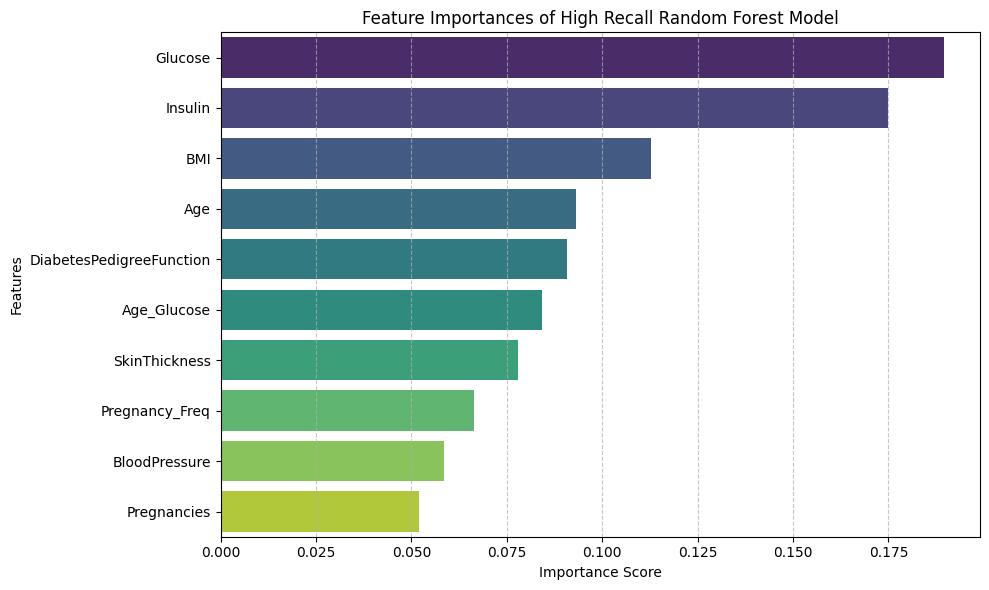

,Feature,Importance
1,Glucose,0.189526
4,Insulin,0.174890
5,BMI,0.112771
7,Age,0.093174
6,DiabetesPedigreeFunction,0.090808
8,Age_Glucose,0.084159
3,SkinThickness,0.077826
9,Pregnancy_Freq,0.066419
2,BloodPressure,0.058432
0,Pregnancies,0.051995


In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# rf_high_recall 모델의 특성 중요도 추출
importances = rf_high_recall.feature_importances_
feature_names = X_train_adv.columns

# 데이터프레임으로 변환 및 정렬
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importances of High Recall Random Forest Model')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 수치 데이터 출력
display(feature_importance_df)